In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("50_Startups.csv")

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.sample(10)

,R&D Spend,Administration,Marketing Spend,State,Profit
16,78013.11,121597.55,264346.06,California,126992.93
7,130298.13,145530.06,323876.68,Florida,155752.60
22,73994.56,122782.75,303319.26,Florida,110352.25
25,64664.71,139553.16,137962.62,California,107404.34
40,28754.33,118546.05,172795.67,California,78239.91
37,44069.95,51283.14,197029.42,California,89949.14
46,1315.46,115816.21,297114.46,Florida,49490.75
44,22177.74,154806.14,28334.72,California,65200.33
23,67532.53,105751.03,304768.73,Florida,108733.99
20,76253.86,113867.30,298664.47,California,118474.03


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [6]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

# EDA

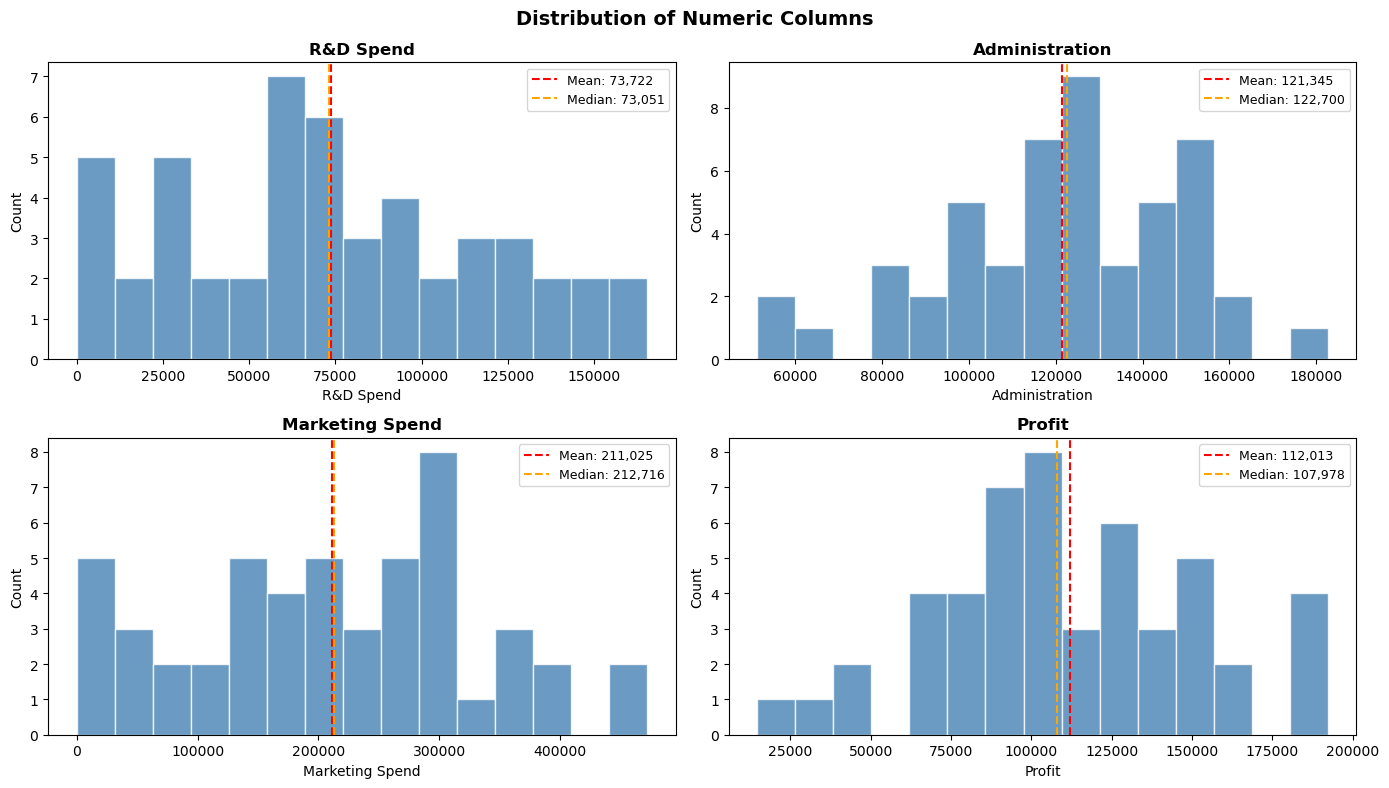

<Figure size 640x480 with 0 Axes>

In [10]:
numeric_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Distribution of Numeric Columns", fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    ax.hist(df[col], bins=15, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean: {df[col].mean():,.0f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', lw=1.5, label=f'Median: {df[col].median():,.0f}')
    ax.set_title(f"{col}", fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig("numeric_distributions.png", dpi=300, bbox_inches='tight')

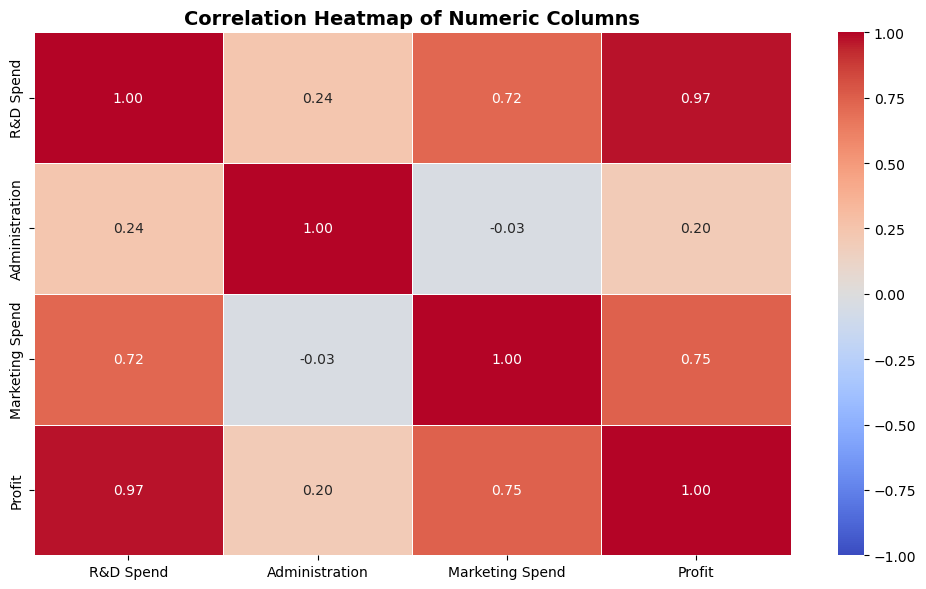

<Figure size 640x480 with 0 Axes>

In [13]:
fig,ax = plt.subplots(figsize=(10, 6))  
numeric_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
corr = df[numeric_cols].corr()

sns.heatmap(corr, 
            annot=True, 
            fmt=".2f",
            cmap='coolwarm', 
            vmax=1, vmin=-1,
            linewidths=0.5, ax=ax)

ax.set_title("Correlation Heatmap of Numeric Columns", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')

Each spend vs Profit colored by state

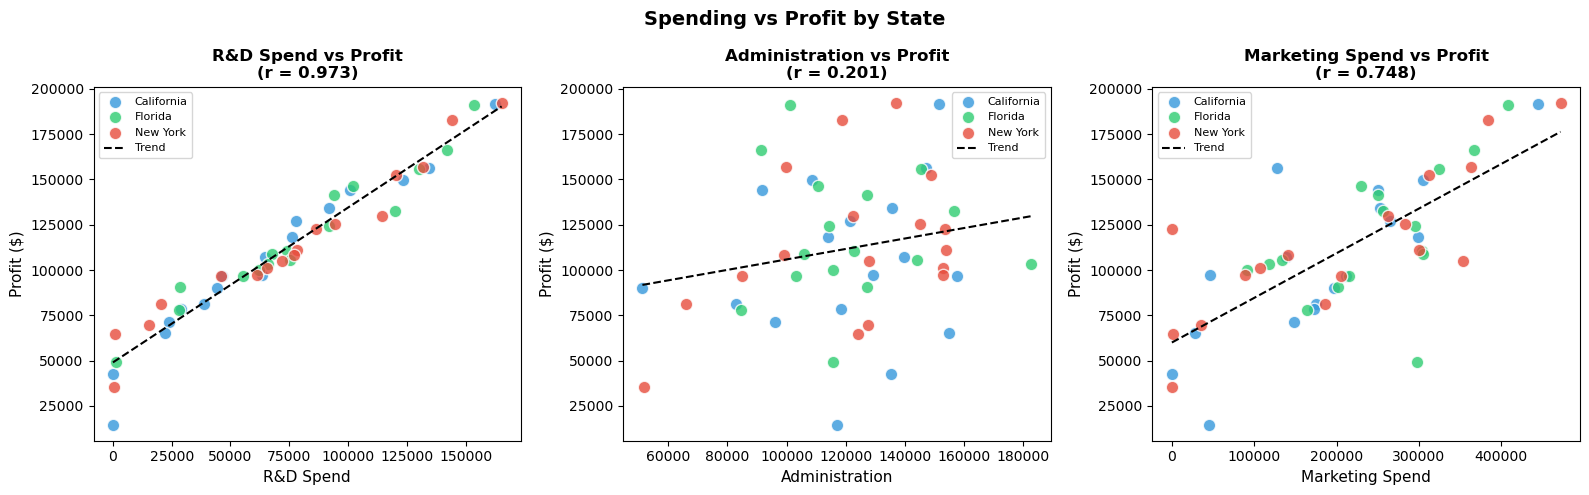

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Spending vs Profit by State", fontsize=14, fontweight='bold')

colors = {'New York': '#e74c3c', 'California': '#3498db', 'Florida': '#2ecc71'}
spend_cols = ['R&D Spend', 'Administration', 'Marketing Spend']

for i, col in enumerate(spend_cols):
    for state, grp in df.groupby('State'):
        axes[i].scatter(grp[col], grp['Profit'],
                        label=state, color=colors[state],
                        alpha=0.8, s=80, edgecolors='white')
    

    z = np.polyfit(df[col], df['Profit'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', lw=1.5, label='Trend')
    
    corr_val = df[col].corr(df['Profit'])
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("Profit ($)", fontsize=11)
    axes[i].set_title(f"{col} vs Profit\n(r = {corr_val:.3f})", fontweight='bold')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("spend_vs_profit.png", dpi=300, bbox_inches='tight')
plt.show()

# Data Preprocessing

In [26]:
X = df.drop(columns=['Profit'])
y = df['Profit']

X = pd.get_dummies(X, columns=['State'] , drop_first=True , dtype=float)

y.head()

0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64

In [27]:
X

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0.0,1.0
1,162597.70,151377.59,443898.53,0.0,0.0
2,153441.51,101145.55,407934.54,1.0,0.0
3,144372.41,118671.85,383199.62,0.0,1.0
4,142107.34,91391.77,366168.42,1.0,0.0
5,131876.90,99814.71,362861.36,0.0,1.0
6,134615.46,147198.87,127716.82,0.0,0.0
7,130298.13,145530.06,323876.68,1.0,0.0
8,120542.52,148718.95,311613.29,0.0,1.0
9,123334.88,108679.17,304981.62,0.0,0.0


# Train Test split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X_train


,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
12,93863.75,127320.38,249839.44,1.0,0.0
4,142107.34,91391.77,366168.42,1.0,0.0
37,44069.95,51283.14,197029.42,0.0,0.0
8,120542.52,148718.95,311613.29,0.0,1.0
3,144372.41,118671.85,383199.62,0.0,1.0
6,134615.46,147198.87,127716.82,0.0,0.0
41,27892.92,84710.77,164470.71,1.0,0.0
46,1315.46,115816.21,297114.46,1.0,0.0
47,0.00,135426.92,0.00,0.0,0.0
15,114523.61,122616.84,261776.23,0.0,1.0


In [30]:
y_test

13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
Name: Profit, dtype: float64

# model 1

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2   = r2_score(y_test, y_pred_lr)

print("── Linear Regression ──────────────────────")
print(f"  MAE  : ${mae:,.2f}")
print(f"  RMSE : ${rmse:,.2f}")
print(f"  R²   : {r2:.4f}")

comparison = pd.DataFrame({
    'Actual'    : y_test.values,
    'Predicted' : y_pred_lr.round(2),
    'Error ($)' : abs(y_test.values - y_pred_lr).round(2)
})
print("\n── Actual vs Predicted ────────────────────")
print(comparison.to_string(index=False))

── Linear Regression ──────────────────────
  MAE  : $6,961.48
  RMSE : $9,055.96
  R²   : 0.8987

── Actual vs Predicted ────────────────────
   Actual  Predicted  Error ($)
134307.35  126362.88    7944.47
 81005.76   84608.45    3602.69
 99937.59   99677.49     260.10
 64926.08   46357.46   18568.62
125370.37  128750.48    3380.11
 35673.41   50912.42   15239.01
105733.54  109741.35    4007.81
107404.34  100643.24    6761.10
 97427.84   97599.28     171.44
122776.86  113097.43    9679.43


# Model 2

In [32]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42) 
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print("\n── Decision Tree Regressor ───────────────")
print(f"  MAE  : ${mae_dt:,.2f}")
print(f"  RMSE : ${rmse_dt:,.2f}")
print(f"  R²   : {r2_dt:.4f}")

comparison_dt = pd.DataFrame({
    'Actual'    : y_test.values,
    'Predicted' : y_pred_dt.round(2),
    'Error ($)' : abs(y_test.values - y_pred_dt).round(2)
})

print("\n── Actual vs Predicted (Decision Tree) ───")
print(comparison_dt.to_string(index=False))



── Decision Tree Regressor ───────────────
  MAE  : $9,131.09
  RMSE : $11,527.66
  R²   : 0.8359

── Actual vs Predicted (Decision Tree) ───
   Actual  Predicted  Error ($)
134307.35  141585.52    7278.17
 81005.76   78239.91    2765.85
 99937.59   97483.56    2454.03
 64926.08   42559.73   22366.35
125370.37  124266.90    1103.47
 35673.41   49490.75   13817.34
105733.54  118474.03   12740.49
107404.34  101004.64    6399.70
 97427.84  101004.64    3576.80
122776.86  141585.52   18808.66


# model 3


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("\n── Random Forest Regressor ───────────────")
print(f"  MAE  : ${mae_rf:,.2f}")
print(f"  RMSE : ${rmse_rf:,.2f}")
print(f"  R²   : {r2_rf:.4f}")

comparison_rf = pd.DataFrame({
    'Actual'    : y_test.values,
    'Predicted' : y_pred_rf.round(2),
    'Error ($)' : abs(y_test.values - y_pred_rf).round(2)
})

print("\n── Actual vs Predicted (Random Forest) ───")
print(comparison_rf.to_string(index=False))



── Random Forest Regressor ───────────────
  MAE  : $6,157.88
  RMSE : $8,418.99
  R²   : 0.9125

── Actual vs Predicted (Random Forest) ───
   Actual  Predicted  Error ($)
134307.35  134048.78     258.57
 81005.76   88731.75    7725.99
 99937.59  100181.36     243.77
 64926.08   44205.47   20720.61
125370.37  130820.87    5450.50
 35673.41   37606.62    1933.21
105733.54  115721.03    9987.49
107404.34  102878.81    4525.53
 97427.84  100750.19    3322.35
122776.86  130187.63    7410.77


# Model comparison


In [ ]:
results = pd.DataFrame({
    'Model' : ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE'   : [mean_absolute_error(y_test, y_pred_lr),
               mean_absolute_error(y_test, y_pred_dt),
               mean_absolute_error(y_test, y_pred_rf)],
    'RMSE'  : [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
               np.sqrt(mean_squared_error(y_test, y_pred_dt)),
               np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    'R²'    : [r2_score(y_test, y_pred_lr),
               r2_score(y_test, y_pred_dt),
               r2_score(y_test, y_pred_rf)]
}).sort_values('R²', ascending=False).reset_index(drop=True)

print("── Model Comparison ───────────────────────────────────────")
print(results.round(4).to_string(index=False))
print(f"\n✅ Best Model: {results.iloc[0]['Model']} (R² = {results.iloc[0]['R²']:.4f})")

── Model Comparison ───────────────────────────────────────
            Model       MAE       RMSE     R²
    Random Forest 6157.8783  8418.9904 0.9125
Linear Regression 6961.4778  9055.9573 0.8987
    Decision Tree 9131.0860 11527.6603 0.8359

✅ Best Model: Random Forest (R² = 0.9125)


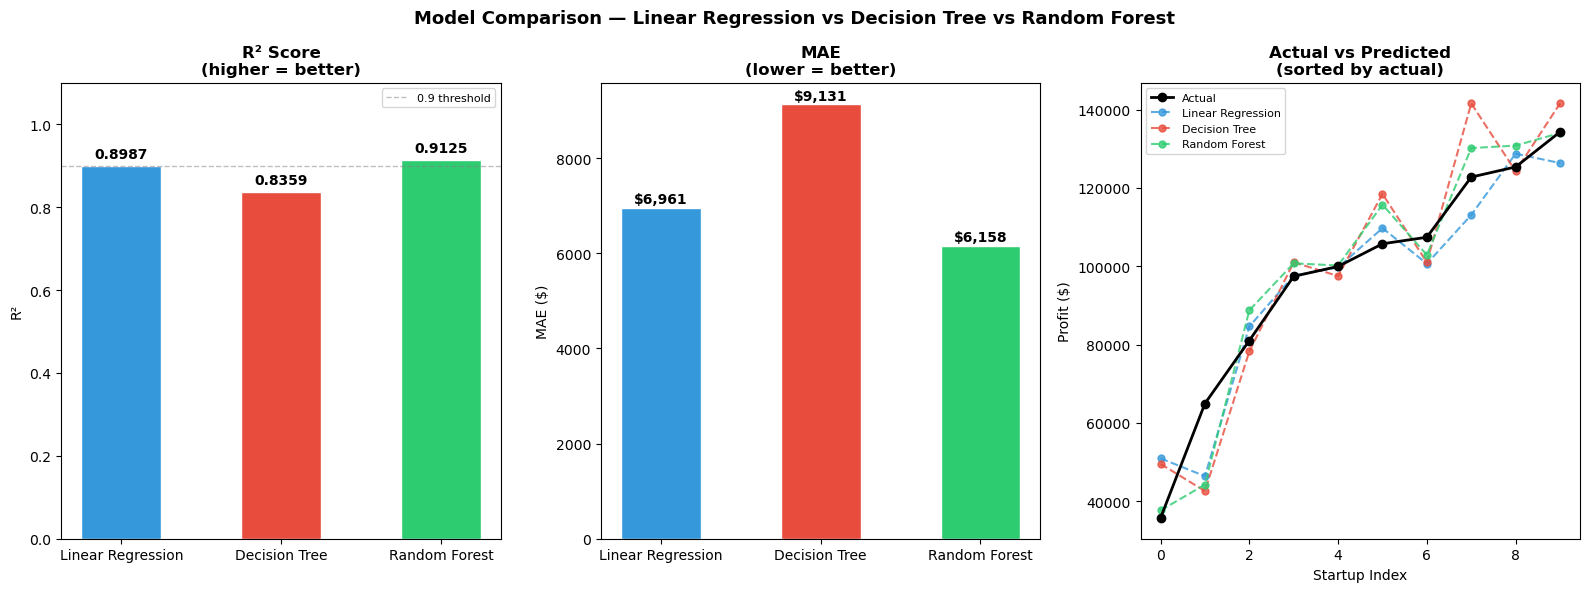

In [37]:
# ── Visualize Comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Model Comparison — Linear Regression vs Decision Tree vs Random Forest",
             fontsize=13, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71']
models_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
preds        = [y_pred_lr, y_pred_dt, y_pred_rf]

# ── Chart 1: R² Bar ───────────────────────────────────────────────────────────
r2_vals = [r2_score(y_test, p) for p in preds]
bars = axes[0].bar(models_names, r2_vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_title("R² Score\n(higher = better)", fontweight='bold')
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[0].axhline(0.9, color='gray', linestyle='--', lw=1, alpha=0.5, label='0.9 threshold')
axes[0].legend(fontsize=8)

# ── Chart 2: MAE Bar ──────────────────────────────────────────────────────────
mae_vals = [mean_absolute_error(y_test, p) for p in preds]
bars = axes[1].bar(models_names, mae_vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title("MAE\n(lower = better)", fontweight='bold')
axes[1].set_ylabel("MAE ($)")
for bar, val in zip(bars, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=10)

# ── Chart 3: Actual vs Predicted for all 3 ───────────────────────────────────
axes[2].plot(range(len(y_test)), sorted(y_test.values),
             'ko-', lw=2, markersize=6, label='Actual', zorder=5)
for name, pred, color in zip(models_names, preds, colors):
    axes[2].plot(range(len(y_test)),
                 [x for _, x in sorted(zip(y_test.values, pred))],
                 'o--', color=color, lw=1.5, markersize=5, alpha=0.8, label=name)
axes[2].set_title("Actual vs Predicted\n(sorted by actual)", fontweight='bold')
axes[2].set_xlabel("Startup Index")
axes[2].set_ylabel("Profit ($)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

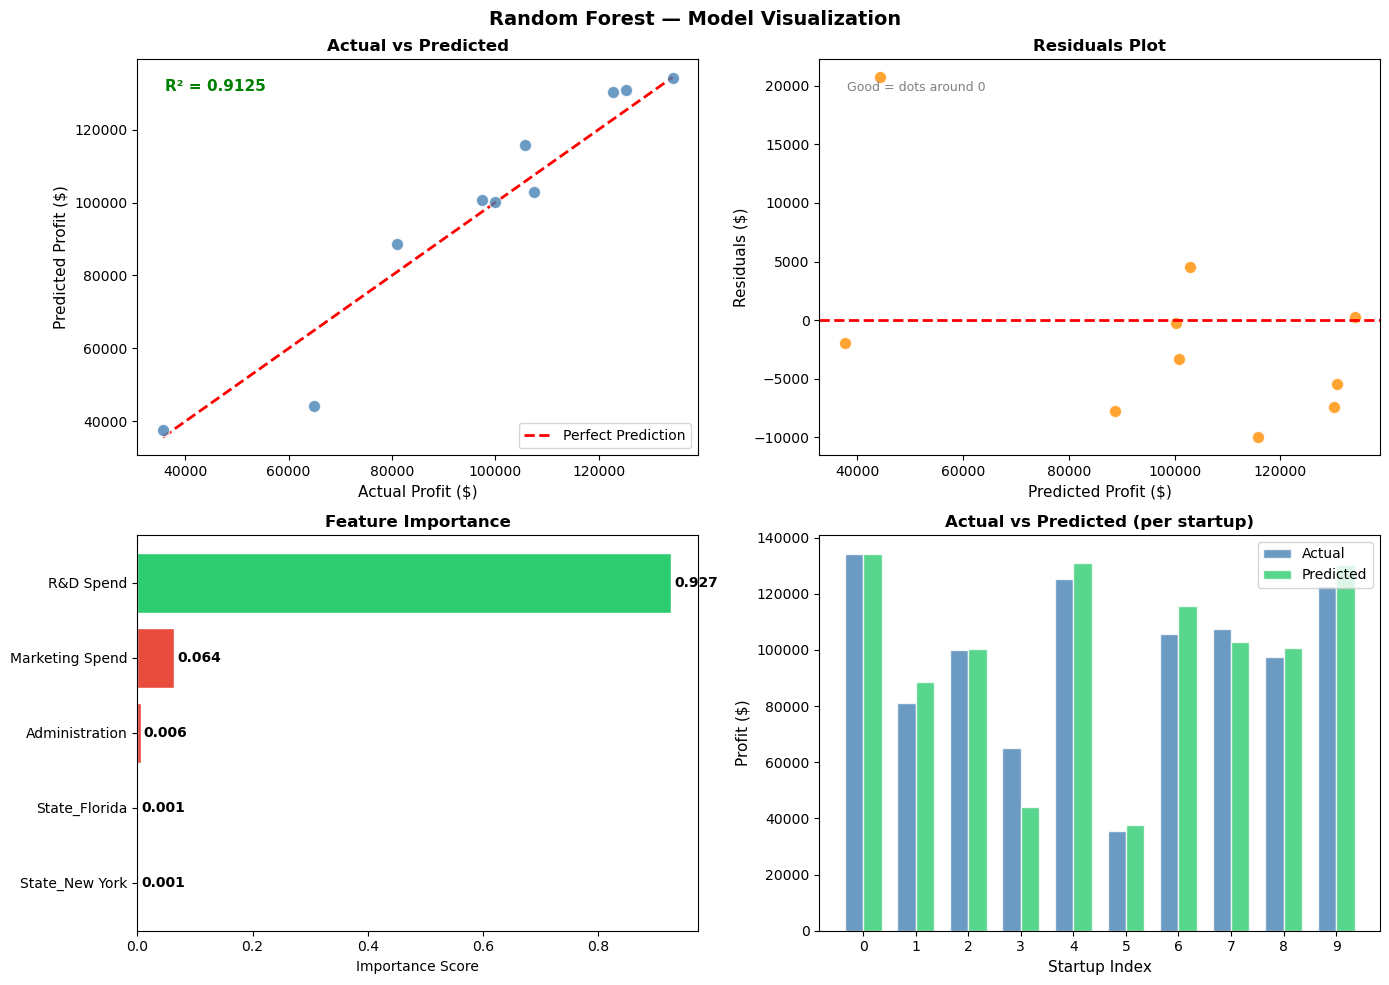

In [39]:
# ── Random Forest Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Random Forest — Model Visualization", fontsize=14, fontweight='bold')

# ── 1. Actual vs Predicted ────────────────────────────────────────────────────
axes[0,0].scatter(y_test, y_pred_rf, color='steelblue', s=80,
                  edgecolors='white', alpha=0.8, zorder=3)
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               'r--', lw=2, label='Perfect Prediction')
axes[0,0].set_xlabel("Actual Profit ($)", fontsize=11)
axes[0,0].set_ylabel("Predicted Profit ($)", fontsize=11)
axes[0,0].set_title("Actual vs Predicted", fontweight='bold')
axes[0,0].text(0.05, 0.92, f'R² = {r2_score(y_test, y_pred_rf):.4f}',
               transform=axes[0,0].transAxes, fontsize=11,
               color='green', fontweight='bold')
axes[0,0].legend()

# ── 2. Residuals Plot ─────────────────────────────────────────────────────────
residuals = y_test.values - y_pred_rf
axes[0,1].scatter(y_pred_rf, residuals, color='darkorange',
                  s=80, edgecolors='white', alpha=0.8)
axes[0,1].axhline(0, color='red', linestyle='--', lw=2)
axes[0,1].set_xlabel("Predicted Profit ($)", fontsize=11)
axes[0,1].set_ylabel("Residuals ($)", fontsize=11)
axes[0,1].set_title("Residuals Plot", fontweight='bold')
axes[0,1].text(0.05, 0.92, 'Good = dots around 0',
               transform=axes[0,1].transAxes, fontsize=9, color='gray')

# ── 3. Feature Importance ─────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

colors_imp = ['#2ecc71' if v > 0.3 else '#3498db' if v > 0.1 else '#e74c3c'
              for v in importances.values]
bars = axes[1,0].barh(importances.index, importances.values,
                      color=colors_imp, edgecolor='white')
axes[1,0].set_title("Feature Importance", fontweight='bold')
axes[1,0].set_xlabel("Importance Score")
for bar, val in zip(bars, importances.values):
    axes[1,0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# ── 4. Actual vs Predicted Bar ────────────────────────────────────────────────
x = np.arange(len(y_test))
width = 0.35
axes[1,1].bar(x - width/2, y_test.values, width, label='Actual',
              color='steelblue', alpha=0.8, edgecolor='white')
axes[1,1].bar(x + width/2, y_pred_rf, width, label='Predicted',
              color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1,1].set_xlabel("Startup Index", fontsize=11)
axes[1,1].set_ylabel("Profit ($)", fontsize=11)
axes[1,1].set_title("Actual vs Predicted (per startup)", fontweight='bold')
axes[1,1].legend()
axes[1,1].set_xticks(x)

plt.tight_layout()
plt.savefig("random_forest_visualization.png", dpi=300, bbox_inches='tight')
plt.show()